# PRO-cap Atlas BPNet dual-locus viewer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kundajelab/procap-atlas/blob/main/notebooks/procap_atlas_bpnet_differential_locus_viewer.ipynb)

Companion to `procap_atlas_bpnet_locus_viewer.ipynb`, for comparing **two experiments at one locus** -- a differentially transcribed gene shown active in one cell type and quiet in another, say. It draws both experiments' observed, predicted, and DeepLIFT/SHAP tracks in one figure, eight rows grouped **by experiment** -- A's observed/predicted/count-DeepLIFT/profile-DeepLIFT, then B's the same way -- with each row labelled directly on the panel (experiment ID and biosample), since with eight otherwise-identical rows there is no other way to tell them apart.

The reason this is a separate notebook rather than a flag on the single-locus one: comparing two independently-rendered figures by pasting them together autoscales each panel to its own data, which erases a genuine difference in magnitude between conditions instead of showing it. This notebook defaults to computing a **shared** axis from both experiments' actual values instead, via `paired_track_ylim`/`paired_logo_clip` in `notebooks/locus_viewer.py`.


## Colab setup

Run this cell first in Colab. It clones the repository into `/content/procap-atlas`, installs the notebook runtime dependencies, and changes the working directory to the checkout. Outside Colab, it leaves the current checkout alone.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_DIR = Path("/content/procap-atlas") if IN_COLAB else Path.cwd()

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/kundajelab/procap-atlas.git",
                str(REPO_DIR),
            ],
            check=True,
        )
    os.chdir(REPO_DIR)
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "bpnet-lite",
            "huggingface-hub",
            "matplotlib",
            "numpy",
            "pandas",
            "pybigtools==0.2.5",
            "pyfaidx",
            "pyyaml",
            "seaborn",
            "tangermeme",
        ],
        check=True,
    )

print(f"Running in Colab: {IN_COLAB}")
print(f"Working directory: {Path.cwd()}")


Running in Colab: False
Working directory: /Users/adamhe/github/procap-atlas/notebooks


## Optional Open OnDemand check

Sherlock Open OnDemand users can set `RUN_ONDEMAND_ENV_CHECK = True` and run this cell after selecting the `PRO-cap Atlas (uv)` kernel. Colab users should leave it disabled.


In [2]:
RUN_ONDEMAND_ENV_CHECK = False

if RUN_ONDEMAND_ENV_CHECK:
    from pathlib import Path as _Path
    import importlib.util as _importlib_util
    import os as _os
    import sys as _sys

    _numpy_spec = _importlib_util.find_spec("numpy")
    _numpy_origin = _Path(_numpy_spec.origin).resolve() if _numpy_spec else None
    _environment_root = _Path(_sys.prefix).resolve()
    print(f"Python: {_sys.executable}")
    print(f"Environment: {_environment_root}")
    print(f"NumPy candidate: {_numpy_origin}")
    print(f"PYTHONPATH: {_os.environ.get('PYTHONPATH')!r}")
    if _os.environ.get("PYTHONPATH"):
        raise RuntimeError(
            "The PRO-cap Atlas kernel did not remove the Open OnDemand PYTHONPATH. "
            "Reinstall it with notebooks/install_uv_kernel.py and restart JupyterLab."
        )
    _ondemand_paths = [
        path
        for path in _sys.path
        if path.startswith("/share/software/user/open/py-jupyterlab/")
    ]
    if _ondemand_paths:
        raise RuntimeError(
            f"Open OnDemand PYTHONPATH entries are affecting imports: {_ondemand_paths}. "
            "Reinstall the kernel with notebooks/install_uv_kernel.py."
        )
    if _numpy_origin is None or not _numpy_origin.is_relative_to(_environment_root):
        raise RuntimeError(
            "NumPy is not resolving from the selected uv environment. Reinstall the "
            "PRO-cap Atlas kernel with notebooks/install_uv_kernel.py."
        )
else:
    print("Skipping Open OnDemand environment check.")


Skipping Open OnDemand environment check.


## Import dependencies

In [3]:
from pathlib import Path
import importlib
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

for _parent in [Path.cwd(), *Path.cwd().parents]:
    if (_parent / "src").is_dir() and str(_parent) not in sys.path:
        sys.path.insert(0, str(_parent))
        break

import notebooks.locus_viewer as locus_viewer

locus_viewer = importlib.reload(locus_viewer)

from notebooks.locus_viewer import (
    best_device,
    call_and_annotate_seqlets,
    cpm_scale_for,
    deeplift_attributions,
    ensemble_prediction,
    logo_offsets_for_region,
    plot_dual_locus_summary,
    region_input,
    save_dual_locus_viewer_outputs,
    setup_experiment,
)

sns.set_style("whitegrid")


/Users/adamhe/github/procap-atlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Choose two experiments and one shared 1-based region of interest -- the same window is used for both experiments' model input, tracks, and DeepLIFT logos, since a differential-locus comparison is inherently about the same genomic window in two conditions. `TRACK_VALUE_CLIP` caps outlier values the same way it does in the single-locus notebook. `LOGO_VALUE_CLIP`/`TRACK_YLIM` fix each panel's axis instead of autoscaling; leave both as `None` (the default) to have them computed automatically from whichever experiment has the larger signal -- that auto behaviour is the reason to prefer this notebook over running the single-locus one twice. Set `SHOW_SEQLETS = True` to call seqlets for both experiments and annotate them against the MEME motif file when it is available.


In [7]:
EXP_ID_A = "ENCSR342WAR"  # neuron
EXP_ID_B = "ENCSR083AMN"  # B cell
REGION = "chr2:181680497-181680896"
REVERSE_COMPLEMENT = True
TRACK_VALUE_CLIP = 200
# None (the default) auto-computes a shared value from both experiments via
# paired_track_ylim/paired_logo_clip. Give an explicit dict, even with some
# keys None, to take manual control of specific rows -- see plot_dual_locus_summary.
LOGO_VALUE_CLIP = None
TRACK_YLIM = None
# Positive:negative split for the axes above, e.g. TRACK_NEGATIVE_FRACTION=0.25
# is a 4:1 split. Two separate knobs, not one: coverage strand balance and
# DeepLIFT sign balance are unrelated properties of unrelated data. 1.0 is
# symmetric. Locus-specific for TRACK_NEGATIVE_FRACTION in particular -- a
# genuinely divergent promoter can have real, comparable plus/minus-strand
# signal, which this would visually suppress; check before trusting it.
TRACK_NEGATIVE_FRACTION = 0.25
LOGO_NEGATIVE_FRACTION = 0.25
# Whether to draw the "{exp_id} ({biosample})\n{kind}" corner label on
# every row -- turn off once you know the row order, for a clean final figure.
SHOW_ROW_LABELS = False
# Whether to draw called seqlets on the DeepLIFT panels, independent of
# whether SHOW_SEQLETS below computes/exports them.
SHOW_SEQLET_ANNOTATIONS = False
SHOW_SEQLETS = False
SEQLET_MOTIF_PATH = Path("data/JASPAR2026_CORE_vertebrates_non-redundant_pfms_meme.txt")
SEQLET_THRESHOLD = 0.05
N_FOLDS = 7
BATCH_SIZE = 8
DEVICE = best_device()  # cuda, else Apple Metal (mps), else cpu
WORK_DIR = Path(os.environ.get("SCRATCH", ".cache")) / "procap_atlas_locus_viewer"
WORK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Work directory: {WORK_DIR}")


Device: mps
Work directory: .cache/procap_atlas_locus_viewer


## Setup, predictions, and DeepLIFT

Run both experiments through the same single-region pipeline as the single-locus notebook (`setup_experiment` -> `region_input` -> `ensemble_prediction` -> `deeplift_attributions`), once per experiment. There are only two calls here, so there is no need for the batched multi-region path the single-locus notebook uses for a sweep over many regions.


In [5]:
def run_experiment(exp_id):
    resources = setup_experiment(exp_id, WORK_DIR, N_FOLDS)
    chrom, region_start, region_end, center, X = region_input(resources, REGION)
    logo_chrom, logo_start, logo_end, logo_offsets = locus_viewer.logo_offsets_for_region(REGION)
    cpm_scale = cpm_scale_for(exp_id)
    prediction = ensemble_prediction(resources, X, N_FOLDS, DEVICE)
    attributions = deeplift_attributions(
        resources, X, logo_offsets, N_FOLDS, BATCH_SIZE, DEVICE
    )
    seqlet_annotations = None
    if SHOW_SEQLETS:
        seqlet_annotations = call_and_annotate_seqlets(
            attributions,
            X,
            logo_offsets,
            motif_path=SEQLET_MOTIF_PATH,
            reverse_complement=REVERSE_COMPLEMENT,
            threshold=SEQLET_THRESHOLD,
        )
    biosample = resources["config"].get("biosample", exp_id)
    print(f"{exp_id} ({biosample}): {X.shape}, logo_offsets={logo_offsets}, "
          f"cpm_scale={cpm_scale}")
    return {
        "resources": resources, "prediction": prediction,
        "attributions": attributions, "seqlet_annotations": seqlet_annotations,
        "cpm_scale": cpm_scale, "logo_start": logo_start, "logo_end": logo_end,
    }


run_a = run_experiment(EXP_ID_A)
run_b = run_experiment(EXP_ID_B)


Predicting fold 1/7 (1 region(s)): ENCSR342WAR.fold0.torch
Predicting fold 2/7 (1 region(s)): ENCSR342WAR.fold1.torch
Predicting fold 3/7 (1 region(s)): ENCSR342WAR.fold2.torch
Predicting fold 4/7 (1 region(s)): ENCSR342WAR.fold3.torch
Predicting fold 5/7 (1 region(s)): ENCSR342WAR.fold4.torch
Predicting fold 6/7 (1 region(s)): ENCSR342WAR.fold5.torch
Predicting fold 7/7 (1 region(s)): ENCSR342WAR.fold6.torch
DeepLIFT fold 1/7 (1 region(s)): ENCSR342WAR.fold0.torch
DeepLIFT fold 2/7 (1 region(s)): ENCSR342WAR.fold1.torch
DeepLIFT fold 3/7 (1 region(s)): ENCSR342WAR.fold2.torch
DeepLIFT fold 4/7 (1 region(s)): ENCSR342WAR.fold3.torch
DeepLIFT fold 5/7 (1 region(s)): ENCSR342WAR.fold4.torch
DeepLIFT fold 6/7 (1 region(s)): ENCSR342WAR.fold5.torch
DeepLIFT fold 7/7 (1 region(s)): ENCSR342WAR.fold6.torch
ENCSR342WAR (neuron): torch.Size([1, 4, 2114]), logo_offsets=(857, 1257), cpm_scale=0.020029878569862665
Predicting fold 1/7 (1 region(s)): ENCSR083AMN.fold0.torch
Predicting fold 2/7 (1 r

## Summary figure

Eight rows, each experiment's own four kept together: A's observed, predicted, counts DeepLIFT, profile DeepLIFT, then B's the same way.


(<Figure size 791.667x333.333 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: xlabel='Genomic position'>], dtype=object))

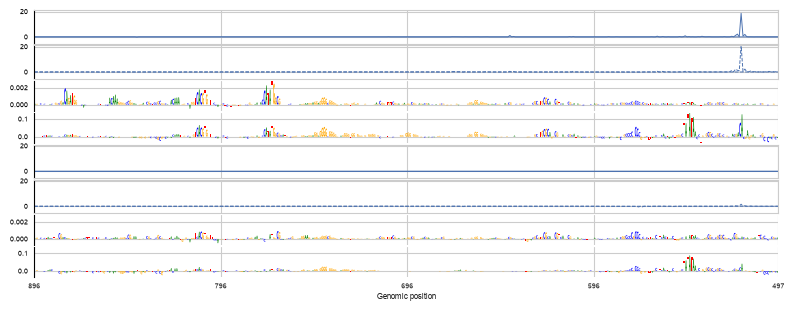

In [8]:
plot_dual_locus_summary(
    run_a["prediction"], run_a["attributions"], run_a["resources"], EXP_ID_A,
    run_b["prediction"], run_b["attributions"], run_b["resources"], EXP_ID_B,
    REGION, REGION, REGION,
    run_a["logo_start"], run_a["logo_end"],
    REVERSE_COMPLEMENT, TRACK_VALUE_CLIP,
    run_a["seqlet_annotations"], run_b["seqlet_annotations"],
    run_a["cpm_scale"], run_b["cpm_scale"],
    LOGO_VALUE_CLIP, TRACK_YLIM,
    TRACK_NEGATIVE_FRACTION, LOGO_NEGATIVE_FRACTION,
    SHOW_ROW_LABELS, SHOW_SEQLET_ANNOTATIONS,
)


## Optional save

Saves the combined figure plus each experiment's raw prediction/attributions, under `plots/bpnet/locus_viewer_dual/{EXP_ID_A}_vs_{EXP_ID_B}/{REGION}/`. Each experiment's raw arrays land in their own `{exp_id}/locus_viewer_arrays.npz` -- the same filename the single-locus notebook uses, one directory per experiment -- always in raw units regardless of any display scaling/clipping used above.


In [9]:
OUTPUT_DIR = (
    Path("plots/bpnet/locus_viewer_dual")
    / f"{EXP_ID_A}_vs_{EXP_ID_B}"
    / REGION.replace(":", "_").replace(",", "")
)
save_dual_locus_viewer_outputs(
    OUTPUT_DIR,
    run_a["prediction"], run_a["attributions"], run_a["resources"], EXP_ID_A,
    run_b["prediction"], run_b["attributions"], run_b["resources"], EXP_ID_B,
    REGION, REGION, REGION,
    run_a["logo_start"], run_a["logo_end"],
    REVERSE_COMPLEMENT, TRACK_VALUE_CLIP,
    run_a["seqlet_annotations"], run_b["seqlet_annotations"],
    run_a["cpm_scale"], run_b["cpm_scale"],
    LOGO_VALUE_CLIP, TRACK_YLIM,
    TRACK_NEGATIVE_FRACTION, LOGO_NEGATIVE_FRACTION,
    SHOW_ROW_LABELS, SHOW_SEQLET_ANNOTATIONS,
)
print(f"Saved {OUTPUT_DIR}")


Saved plots/bpnet/locus_viewer_dual/ENCSR342WAR_vs_ENCSR083AMN/chr2_181680497-181680896
